# **RendaFlex AI**
Assistente Financeiro para pessoas com renda variável.

**O objetivo do projeto** é Classificar transações, Avaliar perfil financeiro e simular decisões.

O dataset utilizado é Synthetic Bank Transactions, do kaggle.com, contendo:

* Clientes – informações básicas sobre os usuários do banco.
* Categorias – categorias padrão de transações utilizadas por muitos bancos em todo o mundo.
* Transações – o núcleo do nosso conjunto de dados, contendo informações básicas sobre as transações, como a conta da contraparte (segunda conta envolvida na transação), a categoria, o valor, entre outros detalhes.
* Assinaturas – informações sobre assinaturas, ou seja, transações realizadas automaticamente.

Além dessas 4 tabelas, usamos também um quinto arquivo, `perfil_financeiro_sintetico.csv`, gerado por
nós. O motivo está explicado na seção 8 — resumindo, o dataset original tem despesa muito maior que
renda pra quase todo cliente (o que não é realista), então a parte de renda/perfil financeiro passou a
vir de uma simulação documentada, enquanto o dataset original continua sendo usado para o que ele faz
bem: classificação de categoria e padrão de consumo.

## 1. Bibliotecas

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import time
import json
import joblib

!pip install deep-translator --quiet
from deep_translator import GoogleTranslator

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)


## 2. Carregando os dados

Cinco arquivos: os 4 originais do Synthetic Bank Transactions, mais o `perfil_financeiro_sintetico.csv`
que geramos à parte pra resolver o problema de escala entre renda e despesa (detalhes na seção 8).

In [46]:
df_clients = pd.read_csv('clients.csv')
df_categories = pd.read_csv('categories.csv')
df_transactions = pd.read_csv('transactions.csv')
df_subscriptions = pd.read_csv('subscriptions.csv')
df_perfil_sintetico = pd.read_csv('perfil_financeiro_sintetico.csv')

for nome, df in [('clients', df_clients), ('categories', df_categories),
                  ('transactions', df_transactions), ('subscriptions', df_subscriptions),
                  ('perfil_sintetico', df_perfil_sintetico)]:
    print(f"{nome}: {df.shape[0]} linhas, {df.shape[1]} colunas")


clients: 1000 linhas, 13 colunas
categories: 29 linhas, 4 colunas
transactions: 929135 linhas, 8 colunas
subscriptions: 1308 linhas, 7 colunas
perfil_sintetico: 1000 linhas, 15 colunas


In [47]:
display(df_clients.head(3))
display(df_categories.head(3))
display(df_transactions.head(3))
display(df_subscriptions.head(3))
display(df_perfil_sintetico.head(3))


,id,fullname,address,phone_number,email,workplace,birthdate,registration_date,gender,income,expenses,credit,deposit
0,1,Волкова Фаина Афанасьевна,"с. Новосибирск, наб. Привокзальная, д. 58 к. 5...",8 (475) 014-6494,wkirillov@rambler.ru,"ст. Кировск (Мурм.), ш. Коммуны, д. 238 стр. 3...",1966-09-07,2017-01-10,F,230910.0,61975,1.0,NaN
1,2,Пелагея Вячеславовна Галкина,"клх Белокуриха, ш. Комсомольское, д. 701 стр. ...",+7 (981) 576-1146,bogdanovmoke@rambler.ru,"г. Елабуга, бул. 60 лет Октября, д. 5, 070955",1987-05-23,2016-07-14,F,NaN,75232,NaN,NaN
2,3,Валентина Игоревна Фомина,"к. Усть-Катав, бул. Восточный, д. 292 стр. 3, ...",+7 (920) 068-58-36,mjasnikovvalentin@mail.ru,"г. Сосновый Бор, алл. Лесхозная, д. 146, 139446",1974-06-15,2017-10-18,F,NaN,88813,NaN,NaN


,id,name,description,mcc-code
0,1,Каршеринг,Краткосрочная аренда авто с оплатой по минутам...,"7512, 4121"
1,2,Супермаркеты,Покупки в супермаркетах и продуктовых магазинах,"5297, 5298, 5300, 5411, 5412, 5422, 5441, 5451..."
2,3,Такси,Услуги такси (каршеринг не входит в данную кат...,4121


,Unnamed: 0,client_id,product_category,product_company,subtype,amount,date,transaction_type
0,34478,37,29,NaN,Автоплатеж,1209,2020-01-01 00:00:00,Negative
1,65406,71,4,YouTube Music,Подписка,169,2020-01-01 00:00:00,Negative
2,82186,88,29,NaN,Автоплатеж,3711,2020-01-01 00:00:00,Negative


,id,client_id,product_category,product_company,amount,date_start,date_end
0,766278,825,29,NaN,3990,2012-01-25,NaN
1,658393,709,4,Яндекс.Музыка,199,2012-01-27,2020-02-27
2,354548,383,4,Boom,149,2012-01-28,NaN


,id_cliente,perfil_renda_origem,renda_media,renda_desvio,coef_variacao_renda,meses_com_renda,renda_confiavel,despesa_media_mensal,despesa_fixa_total,despesa_fixa_mensal_media,saldo_medio_mensal,comprometimento_fixo,idade,genero,perfil_financeiro
0,1,alto,3651.45,1507.65,0.4129,12,True,2546.19,8046.12,670.51,1105.26,0.1836,54,F,Em observação
1,2,moderado,3130.82,833.48,0.2662,12,True,3712.06,14579.16,1214.93,-581.24,0.3881,33,F,Em risco
2,3,alto,5438.19,2456.60,0.4517,12,True,4427.53,14068.44,1172.37,1010.66,0.2156,46,F,Em observação


## 3. Traduzindo do russo pro português

As 29 categorias do dataset são uma lista pequena e fixa, então em vez de depender de uma API externa
de tradução (que pode falhar por causa de internet, limite de requisição, ou simplesmente não estar
disponível no ambiente onde o notebook está rodando), traduzimos elas com um dicionário fixo, feito à
mão uma única vez. Isso deixa essa etapa 100% confiável e reproduzível, sem depender de nada externo.

Já os nomes de empresa em `subscriptions.csv` são texto mais variado (não dá pra prever todos de
antemão), então ali sim usamos um tradutor automático como estimativa — com cache pra não repetir a
mesma tradução, e um aviso caso a tradução não esteja disponível no ambiente (nesse caso o nome original
em russo é mantido, o que não trava o pipeline, só deixa aquele campo específico sem tradução).

In [48]:
# Dicionário fixo com as 29 categorias do dataset (feito uma vez, não depende de internet)
DE_PARA_CATEGORIAS = {
    "Каршеринг": "Carsharing",
    "Супермаркеты": "Supermercados",
    "Такси": "Táxi",
    "Музыка": "Música",
    "Фастфуд": "Fast food",
    "Транспорт": "Transporte",
    "Аптеки": "Farmácias",
    "Кино": "Cinema",
    "Книги": "Livros",
    "Развлечения": "Entretenimento",
    "Красота": "Beleza",
    "Образование": "Educação",
    "Одежда и обувь": "Roupas e calçados",
    "Рестораны": "Restaurantes",
    "Топливо": "Combustível",
    "Животные": "Pet shop",
    "Дом и ремонт": "Casa e reforma",
    "Спорттовары": "Artigos esportivos",
    "Сувениры": "Souvenirs",
    "Фото и видео": "Foto e vídeo",
    "Цветы": "Flores",
    "Аренда авто": "Aluguel de carro",
    "Автоуслуги": "Serviços automotivos",
    "Авиабилеты": "Passagens aéreas",
    "Дьюти-фри": "Duty free",
    "Железнодорожные билеты": "Passagens de trem",
    "Искусство": "Arte",
    "Переводы": "Transferências",
    "Другое": "Outros",
}

df_categories = df_categories.rename(columns={
    'id': 'id_categoria',
    'name': 'categoria',
    'mcc-code': 'codigo_mcc'
})

df_categories['categoria'] = df_categories['categoria'].map(DE_PARA_CATEGORIAS).fillna(df_categories['categoria'])

# a coluna description original é uma explicação mais longa de cada categoria; como ela não é usada
# em nenhum cálculo do notebook (só a coluna 'categoria' é), não entra no dicionário manual
df_categories = df_categories.drop(columns=['description'])

display(df_categories.head(29))


,id_categoria,categoria,codigo_mcc
0,1,Carsharing,"7512, 4121"
1,2,Supermercados,"5297, 5298, 5300, 5411, 5412, 5422, 5441, 5451..."
2,3,Táxi,4121
3,4,Música,"5733, 5735"
4,5,Fast food,5814
5,6,Transporte,"4111, 4121, 4131, 4457, 4468, 4784, 4789, 5013..."
6,7,Farmácias,"5122, 5292, 5295, 5912"
7,8,Cinema,"7829, 7832, 7841"
8,9,Livros,"2741, 5111, 5192, 5942, 5994"
9,10,Entretenimento,"7911, 7922, 7929, 7932, 7933, 7941, 7991, 7992..."


In [49]:
# Tradutor automático, usado só aqui pra nomes de empresa (texto mais variado que categoria).
# Se o ambiente não tiver acesso à internet, a tradução falha silenciosamente e o nome original
# em russo é mantido -- isso não trava o notebook, só deixa esse campo específico sem tradução.
tradutor = GoogleTranslator(source='ru', target='pt')
_cache_traducao = {}

def traduzir(texto, tentativas=2):
    """Traduz um texto do russo pro português, com cache. Se falhar (ex: sem internet),
    devolve o texto original sem travar o notebook."""
    if pd.isna(texto) or str(texto).strip() == '':
        return texto
    texto = str(texto)
    if texto in _cache_traducao:
        return _cache_traducao[texto]
    for tentativa in range(tentativas):
        try:
            traduzido = tradutor.translate(texto)
            _cache_traducao[texto] = traduzido
            return traduzido
        except Exception:
            time.sleep(1)
    _cache_traducao[texto] = texto
    return texto

def traduzir_coluna(df, coluna):
    """Traduz só os valores únicos de uma coluna e aplica o de-para na coluna inteira."""
    valores_unicos = df[coluna].dropna().unique()
    de_para = {v: traduzir(v) for v in valores_unicos}
    return df[coluna].map(de_para).fillna(df[coluna])


In [50]:
df_subscriptions['product_company'] = traduzir_coluna(df_subscriptions, 'product_company')

df_subscriptions = df_subscriptions.rename(columns={
    'client_id': 'id_cliente',
    'product_category': 'id_categoria',
    'product_company': 'empresa',
    'amount': 'valor',
    'date_start': 'data_inicio',
    'date_end': 'data_fim'
})

qtd_nao_traduzido = df_subscriptions['empresa'].apply(lambda x: any('\u0400' <= c <= '\u04FF' for c in str(x))).sum()
if qtd_nao_traduzido > 0:
    print(f"Aviso: {qtd_nao_traduzido} nomes de empresa continuam em russo "
          f"(provavelmente sem acesso à internet nesse ambiente). Não afeta o restante do notebook, "
          f"já que 'empresa' é usada só como informação de apoio (seção 5), não em nenhum cálculo.")

display(df_subscriptions.head(10))


,id,id_cliente,id_categoria,empresa,valor,data_inicio,data_fim
0,766278,825,29,NaN,3990,2012-01-25,NaN
1,658393,709,4,Yandex.Música,199,2012-01-27,2020-02-27
2,354548,383,4,Boom,149,2012-01-28,NaN
3,515830,556,4,Spotify,169,2012-02-01,NaN
4,799560,862,4,Música do YouTube,169,2012-02-20,2020-05-20
5,597370,643,4,Música do YouTube,169,2012-02-28,NaN
6,522160,562,29,NaN,1778,2012-03-07,NaN
7,692999,747,4,Música da Apple,169,2012-03-09,NaN
8,781838,843,4,Yandex.Música,199,2012-03-28,NaN
9,521377,562,4,Yandex.Música,199,2012-05-09,2020-10-09


## 4. Preparando as transações

Ajustamos nomes de coluna, convertemos a data e trazemos o nome da categoria (já traduzida) pra cada
transação. Também traduzimos a coluna `subtipo` (indica se a transação é pagamento automático, assinatura,
compra pontual, etc.) — isso importa porque ajuda a diferenciar gasto pontual de gasto fixo/recorrente,
um ponto que o time de Back levantou e faz sentido.

In [51]:
DE_PARA_SUBTIPO = {
    "Автоплатеж": "Pagamento automático",
    "Подписка": "Assinatura",
    "Покупка": "Compra",
    "Пополнение": "Recarga",
    "Перевод": "Transferência",
}

df_transactions_clean = df_transactions.rename(columns={
    'client_id': 'id_cliente',
    'product_category': 'id_categoria',
    'product_company': 'empresa',
    'subtype': 'subtipo',
    'amount': 'valor',
    'date': 'data',
    'transaction_type': 'tipo_transacao'
}).drop(columns=[c for c in ['Unnamed: 0'] if c in df_transactions.columns])

df_transactions_clean['subtipo'] = df_transactions_clean['subtipo'].map(DE_PARA_SUBTIPO).fillna(df_transactions_clean['subtipo'])

df_transactions_clean['data'] = pd.to_datetime(df_transactions_clean['data'])
df_transactions_clean['ano_mes'] = df_transactions_clean['data'].dt.to_period('M')

df_transactions_clean = df_transactions_clean.merge(
    df_categories[['id_categoria', 'categoria', 'codigo_mcc']],
    on='id_categoria', how='left'
)

print(df_transactions_clean['tipo_transacao'].value_counts())
print()
print(df_transactions_clean['subtipo'].value_counts())
display(df_transactions_clean.head(5))


tipo_transacao
Negative    884151
Positive     44984
Name: count, dtype: int64

subtipo
Compra                  825927
Transferência            45034
Recarga                  44984
Assinatura                8004
Pagamento automático      5186
Name: count, dtype: int64


,id_cliente,id_categoria,empresa,subtipo,valor,data,tipo_transacao,ano_mes,categoria,codigo_mcc
0,37,29,NaN,Pagamento automático,1209,2020-01-01,Negative,2020-01,Outros,NaN
1,71,4,YouTube Music,Assinatura,169,2020-01-01,Negative,2020-01,Música,"5733, 5735"
2,88,29,NaN,Pagamento automático,3711,2020-01-01,Negative,2020-01,Outros,NaN
3,89,29,NaN,Pagamento automático,6443,2020-01-01,Negative,2020-01,Outros,NaN
4,141,29,NaN,Pagamento automático,7319,2020-01-01,Negative,2020-01,Outros,NaN


## 5. Assinaturas como apoio qualitativo

Não usamos mais `subscriptions.csv` pra calcular o valor da despesa fixa (isso já vem simulado no
arquivo de perfil). Mas continua útil pra dar exemplos realistas de "assinatura recorrente" — por
exemplo, pra mostrar no pitch quais empresas aparecem mais como gasto fixo entre os clientes.

In [52]:
top_assinaturas = df_subscriptions['empresa'].value_counts().head(10)
print("Assinaturas mais comuns no dataset original (uso qualitativo/apoio):")
print(top_assinaturas)


Assinaturas mais comuns no dataset original (uso qualitativo/apoio):
empresa
Google Play Música    158
Yandex.Música         141
Música do YouTube     136
Boom                  131
Spotify               122
Música da Apple       113
Name: count, dtype: int64


## 6. Organizando os dados demográficos dos clientes

De `clients.csv` ficamos só com o que tem valor pro modelo: idade e gênero. Nome, endereço, telefone,
e-mail, local de trabalho e os campos financeiros (`income`, `expenses`, `credit`, `deposit`) saem —
os financeiros porque são justamente os campos que geravam a distorção original entre renda e despesa,
substituídos agora pelo arquivo sintético.

In [53]:
df_clients_clean = df_clients.rename(columns={'id': 'id_cliente', 'birthdate': 'data_nascimento', 'gender': 'genero'})
df_clients_clean['data_nascimento'] = pd.to_datetime(df_clients_clean['data_nascimento'], errors='coerce')
df_clients_clean['idade'] = (pd.Timestamp('2020-12-31') - df_clients_clean['data_nascimento']).dt.days // 365
df_clients_clean = df_clients_clean[['id_cliente', 'idade', 'genero']]

display(df_clients_clean.head(5))


,id_cliente,idade,genero
0,1,54,F
1,2,33,F
2,3,46,F
3,4,41,F
4,5,34,M


## 7. Por que criamos um dataset sintético de renda e perfil

Ao calcular renda e despesa reais a partir de `transactions.csv`, a despesa média mensal por cliente
saiu ~14x maior que a renda média mensal — o que não é realista e fazia o modelo classificar 100% dos
clientes como "Em risco". Investigando, a causa é que o dataset tem muito mais transações de despesa
(cartão, compras do dia a dia) do que de renda (poucos depósitos grandes por ano) — ele parece simular
só o fluxo de pagamentos, não a renda completa da pessoa.

Decisão tomada com o time: manter o `transactions.csv` só para classificação de categoria e padrão de
consumo (onde ele funciona bem), e gerar separadamente um dataset simulado — documentado e reprodutível
— só pra parte de renda/perfil financeiro. Esse é o `perfil_financeiro_sintetico.csv`.

Resumo de como ele foi gerado (script à parte, com seed fixa = 42, reprodutível):
- Cada cliente recebe um perfil de renda sorteado: Estável (35%), Moderadamente variável (40%) ou
  Altamente variável (25%) — pesando mais pro público-alvo de renda variável do projeto.
- A renda-base mensal segue distribuição log-normal (média ~R\$3.800), e a instabilidade de renda
  (coeficiente de variação) reflete o perfil sorteado.
- A despesa é sorteada como fração da própria renda do cliente (mantendo despesa e renda na mesma
  escala, ao contrário do dataset original).
- A despesa fixa é uma fração da despesa total.
- O perfil final (Saudável / Em observação / Em risco) usa a mesma regra de negócio do notebook,
  aplicada em cima desses números simulados.

In [54]:
features_cliente = df_perfil_sintetico.merge(df_clients_clean[['id_cliente']], on='id_cliente', how='inner')
# idade/gênero já vêm dentro do próprio arquivo sintético (foram herdados do clients.csv na geração)

print(features_cliente['perfil_financeiro'].value_counts())
display(features_cliente.head(10))


perfil_financeiro
Saudável         498
Em observação    343
Em risco         159
Name: count, dtype: int64


,id_cliente,perfil_renda_origem,renda_media,renda_desvio,coef_variacao_renda,meses_com_renda,renda_confiavel,despesa_media_mensal,despesa_fixa_total,despesa_fixa_mensal_media,saldo_medio_mensal,comprometimento_fixo,idade,genero,perfil_financeiro
0,1,alto,3651.45,1507.65,0.4129,12,True,2546.19,8046.12,670.51,1105.26,0.1836,54,F,Em observação
1,2,moderado,3130.82,833.48,0.2662,12,True,3712.06,14579.16,1214.93,-581.24,0.3881,33,F,Em risco
2,3,alto,5438.19,2456.60,0.4517,12,True,4427.53,14068.44,1172.37,1010.66,0.2156,46,F,Em observação
3,4,moderado,3417.39,703.50,0.2059,12,True,3434.65,7643.28,636.94,-17.26,0.1864,41,F,Em risco
4,5,estavel,3310.13,247.24,0.0747,12,True,2682.55,14579.40,1214.95,627.58,0.3670,34,M,Saudável
5,6,alto,3983.30,1836.92,0.4612,12,True,3244.26,17721.00,1476.75,739.04,0.3707,59,F,Em observação
6,7,alto,8153.65,3920.61,0.4808,12,True,5828.84,47221.92,3935.16,2324.81,0.4826,37,F,Em observação
7,8,alto,2078.90,831.59,0.4000,12,True,1749.27,6711.96,559.33,329.63,0.2691,48,F,Em observação
8,9,estavel,5373.27,150.03,0.0279,12,True,4713.65,26269.08,2189.09,659.62,0.4074,49,F,Em observação
9,10,moderado,1621.05,446.17,0.2752,12,True,1100.42,6165.48,513.79,520.63,0.3169,32,M,Saudável


## 8. Conferindo se a base sintética faz sentido

Checagem visual rápida: instabilidade de renda e comprometimento com despesa fixa devem crescer conforme
o perfil piora (Saudável -> Em observação -> Em risco). Se os grupos aparecessem todos misturados, seria
sinal de que algo na simulação precisa de ajuste.

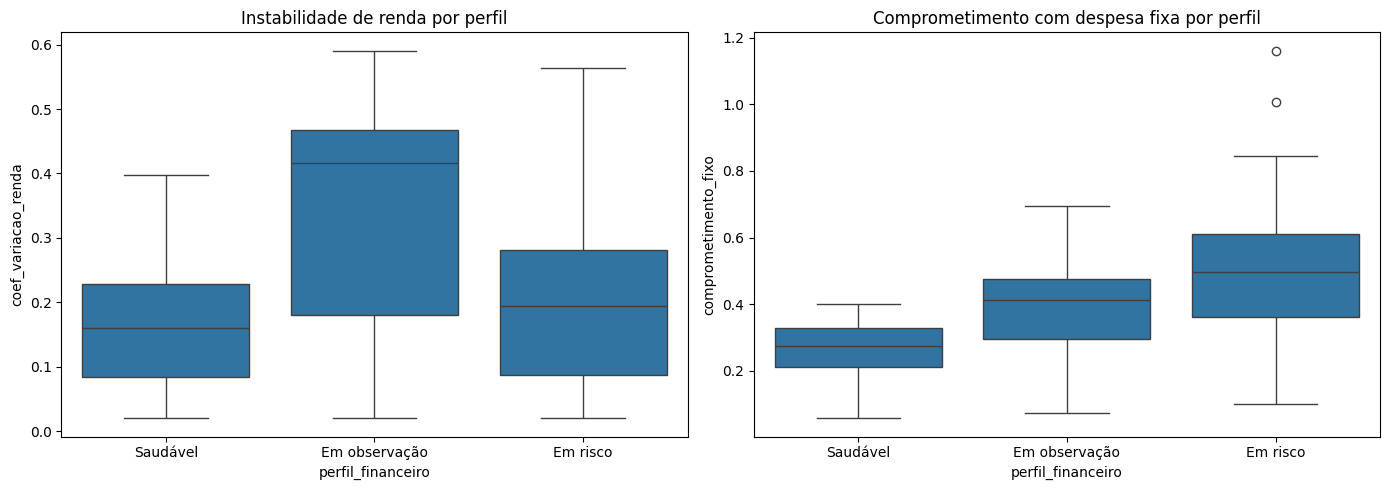

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=features_cliente, x='perfil_financeiro', y='coef_variacao_renda',
            order=['Saudável', 'Em observação', 'Em risco'], ax=axes[0])
axes[0].set_title('Instabilidade de renda por perfil')

sns.boxplot(data=features_cliente, x='perfil_financeiro', y='comprometimento_fixo',
            order=['Saudável', 'Em observação', 'Em risco'], ax=axes[1])
axes[1].set_title('Comprometimento com despesa fixa por perfil')

plt.tight_layout()
plt.show()


## 9. Classificando a descrição da transação em categoria

Aqui voltamos a usar o `transactions.csv` — a parte que ele resolve bem. O objetivo é treinar um modelo
que, dado um texto de descrição de transação (ex: "Supermercado", "Netflix"), preveja em qual categoria
do hackathon ela se encaixa (Alimentação, Transporte, Saúde, Moradia, Educação, Lazer, Serviços, Outras).

Como o dataset não tem descrição livre de transação (só categoria numérica), montamos aqui uma base de
exemplos descrição -> categoria pra treinar esse classificador. Isso é um ponto de partida pra provar o
pipeline funcionando; o ideal é o time trocar/ampliar essa base por uma fonte real de descrições assim
que definirem qual usar.

In [56]:
exemplos_descricao = pd.DataFrame([
    ("Supermercado Extra", "Alimentação"),
    ("iFood pedido restaurante", "Alimentação"),
    ("Feira livre", "Alimentação"),
    ("Padaria do bairro", "Alimentação"),
    ("Posto de gasolina", "Transporte"),
    ("Uber viagem centro", "Transporte"),
    ("Passagem de ônibus", "Transporte"),
    ("Estacionamento shopping", "Transporte"),
    ("Farmácia remédio", "Saúde"),
    ("Consulta médica particular", "Saúde"),
    ("Plano de saúde mensalidade", "Saúde"),
    ("Academia mensalidade", "Saúde"),
    ("Aluguel apartamento", "Moradia"),
    ("Conta de luz", "Moradia"),
    ("Conta de água", "Moradia"),
    ("Condomínio mensal", "Moradia"),
    ("Mensalidade faculdade", "Educação"),
    ("Curso online plataforma", "Educação"),
    ("Material escolar", "Educação"),
    ("Livro técnico", "Educação"),
    ("Netflix assinatura", "Lazer"),
    ("Cinema ingresso", "Lazer"),
    ("Show de música", "Lazer"),
    ("Spotify assinatura", "Lazer"),
    ("Salão de beleza", "Serviços"),
    ("Conserto celular", "Serviços"),
    ("Assinatura software", "Serviços"),
    ("Plano de celular", "Serviços"),
    ("Transferência entre contas", "Outras"),
    ("Saque em caixa eletrônico", "Outras"),
], columns=["descricao", "categoria"])

display(exemplos_descricao)


,descricao,categoria
0,Supermercado Extra,Alimentação
1,iFood pedido restaurante,Alimentação
2,Feira livre,Alimentação
3,Padaria do bairro,Alimentação
4,Posto de gasolina,Transporte
5,Uber viagem centro,Transporte
6,Passagem de ônibus,Transporte
7,Estacionamento shopping,Transporte
8,Farmácia remédio,Saúde
9,Consulta médica particular,Saúde


In [57]:
X_texto = exemplos_descricao['descricao']
y_texto = exemplos_descricao['categoria']

X_texto_treino, X_texto_teste, y_texto_treino, y_texto_teste = train_test_split(
    X_texto, y_texto, test_size=0.25, random_state=42, stratify=y_texto
)

vetorizador_tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1, 2))
X_texto_treino_vet = vetorizador_tfidf.fit_transform(X_texto_treino)
X_texto_teste_vet = vetorizador_tfidf.transform(X_texto_teste)

modelo_categoria = MultinomialNB()
modelo_categoria.fit(X_texto_treino_vet, y_texto_treino)

y_texto_pred = modelo_categoria.predict(X_texto_teste_vet)

print("Acurácia:", accuracy_score(y_texto_teste, y_texto_pred))
print()
print(classification_report(y_texto_teste, y_texto_pred, zero_division=0))


Acurácia: 0.25

              precision    recall  f1-score   support

 Alimentação       0.17      1.00      0.29         1
    Educação       0.00      0.00      0.00         1
       Lazer       0.00      0.00      0.00         1
     Moradia       0.00      0.00      0.00         1
      Outras       0.00      0.00      0.00         1
       Saúde       0.00      0.00      0.00         1
    Serviços       1.00      1.00      1.00         1
  Transporte       0.00      0.00      0.00         1

    accuracy                           0.25         8
   macro avg       0.15      0.25      0.16         8
weighted avg       0.15      0.25      0.16         8



## 10. Treinando o modelo de perfil financeiro

Primeiro treinamos com todas as variáveis candidatas, incluindo idade, só pra medir o quanto cada uma
pesa na decisão do modelo. O time de Back levantou uma dúvida válida: será que idade tem impacto real,
ou é só um campo a mais que pode introduzir viés sem necessidade? Em vez de decidir isso no achismo,
deixamos o próprio modelo responder — se a importância da idade for baixa (< 5%), treinamos a versão
final sem ela.

In [58]:
colunas_candidatas = [
    'renda_media', 'coef_variacao_renda', 'despesa_media_mensal',
    'comprometimento_fixo', 'saldo_medio_mensal', 'idade'
]

base_modelo = features_cliente.dropna(subset=colunas_candidatas + ['perfil_financeiro']).copy()

X_teste_importancia = base_modelo[colunas_candidatas]
y_teste_importancia = base_modelo['perfil_financeiro']

modelo_avaliacao_features = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
modelo_avaliacao_features.fit(X_teste_importancia, y_teste_importancia)

importancias = pd.Series(
    modelo_avaliacao_features.feature_importances_, index=colunas_candidatas
).sort_values(ascending=False)

print("Importância de cada variável (modelo com todas as candidatas):")
print(importancias)

LIMIAR_IMPORTANCIA = 0.05
if importancias.get('idade', 0) < LIMIAR_IMPORTANCIA:
    colunas_features = [c for c in colunas_candidatas if c != 'idade']
    print(f"\nIdade teve importância {importancias.get('idade', 0):.1%}, abaixo do limiar de "
          f"{LIMIAR_IMPORTANCIA:.0%} — removendo do modelo final pra evitar campo sem impacto claro.")
else:
    colunas_features = colunas_candidatas
    print(f"\nIdade teve importância {importancias.get('idade', 0):.1%}, mantida no modelo final.")

print("Colunas usadas no modelo final:", colunas_features)


Importância de cada variável (modelo com todas as candidatas):
saldo_medio_mensal      0.446519
comprometimento_fixo    0.260198
coef_variacao_renda     0.221627
despesa_media_mensal    0.035972
renda_media             0.024591
idade                   0.011094
dtype: float64

Idade teve importância 1.1%, abaixo do limiar de 5% — removendo do modelo final pra evitar campo sem impacto claro.
Colunas usadas no modelo final: ['renda_media', 'coef_variacao_renda', 'despesa_media_mensal', 'comprometimento_fixo', 'saldo_medio_mensal']


In [59]:
X_perfil = base_modelo[colunas_features]
y_perfil = base_modelo['perfil_financeiro']

X_perfil_treino, X_perfil_teste, y_perfil_treino, y_perfil_teste = train_test_split(
    X_perfil, y_perfil, test_size=0.2, random_state=42, stratify=y_perfil
)

modelo_perfil = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
modelo_perfil.fit(X_perfil_treino, y_perfil_treino)

y_perfil_pred = modelo_perfil.predict(X_perfil_teste)

print("Acurácia:", accuracy_score(y_perfil_teste, y_perfil_pred))
print("F1 (média ponderada):", f1_score(y_perfil_teste, y_perfil_pred, average='weighted'))
print()
print(classification_report(y_perfil_teste, y_perfil_pred, zero_division=0))


Acurácia: 0.99
F1 (média ponderada): 0.9900219587176109

               precision    recall  f1-score   support

Em observação       0.97      1.00      0.99        68
     Em risco       1.00      1.00      1.00        32
     Saudável       1.00      0.98      0.99       100

     accuracy                           0.99       200
    macro avg       0.99      0.99      0.99       200
 weighted avg       0.99      0.99      0.99       200



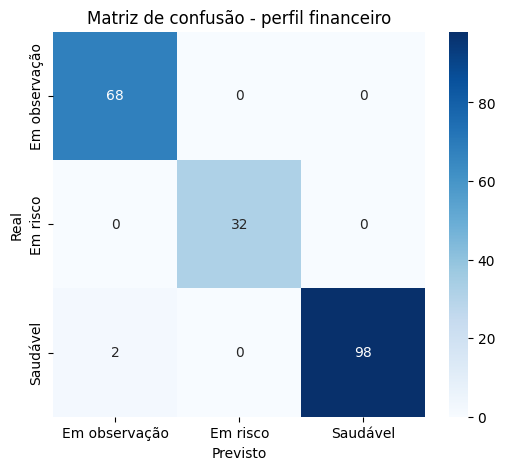

saldo_medio_mensal      0.457895
comprometimento_fixo    0.263516
coef_variacao_renda     0.226032
despesa_media_mensal    0.032025
renda_media             0.020532
dtype: float64


In [60]:
matriz = confusion_matrix(y_perfil_teste, y_perfil_pred, labels=modelo_perfil.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_perfil.classes_, yticklabels=modelo_perfil.classes_)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de confusão - perfil financeiro')
plt.show()

importancias = pd.Series(modelo_perfil.feature_importances_, index=colunas_features).sort_values(ascending=False)
print(importancias)


## 11. Salvando os modelos treinados

Serializamos os dois modelos (categoria de despesa e perfil financeiro) junto com o vetorizador TF-IDF.
É esse arquivo que o back-end vai carregar pra não precisar retreinar nada a cada chamada da API.

In [61]:
joblib.dump(modelo_categoria, 'modelo_categoria_despesa.pkl')
joblib.dump(vetorizador_tfidf, 'vetorizador_tfidf_categoria.pkl')
joblib.dump(modelo_perfil, 'modelo_perfil_financeiro.pkl')
joblib.dump(colunas_features, 'colunas_features_modelo_perfil.pkl')  # lista de variáveis que o modelo espera

features_cliente.to_csv('features_cliente_rendaflex.csv', index=False)
df_categories.to_csv('categorias_traduzidas.csv', index=False)

print("Modelos e tabelas salvos com sucesso.")
print("Variáveis que o modelo de perfil espera receber:", colunas_features)


Modelos e tabelas salvos com sucesso.
Variáveis que o modelo de perfil espera receber: ['renda_media', 'coef_variacao_renda', 'despesa_media_mensal', 'comprometimento_fixo', 'saldo_medio_mensal']


## 12. Função de inferência (o que a API vai chamar)

Essa é a versão 0.3, já incorporando o retorno do time de Back **e duas correções encontradas nesta revisão**:

- **`historico_renda`** entra como lista de valores mensais (não mais um número único). É a partir dela
  que a função calcula `renda_media` e `coef_variacao_renda` de verdade — que é o cerne da tese de renda
  variável do projeto.
- **`dividas_mensais`** entra como valor bruto (soma de dívidas/parcelas do mês), e o `nivel_endividamento`
  em percentual é calculado aqui dentro, não recebido pronto — evita que cada integração calcule esse
  percentual de um jeito diferente.
- **Correção do bug do `resumo_gastos`**: antes, toda transação passava pelo classificador de texto, mesmo
  quando a `descricao` já era o próprio nome de uma categoria conhecida (o que causava classificação errada,
  tipo "Transporte" virar "Alimentação"). Agora, se a descrição já bate com uma categoria conhecida, ela é
  usada direto; o classificador de texto só entra quando a descrição é texto livre de verdade (ex: "posto
  de gasolina", que é o caso de uso real do usuário final digitando).
- Removemos `idade` da entrada, já que ficou fora do modelo final (seção 10).
- **[NOVO] Correção do cálculo de `comprometimento_fixo`**: a versão anterior calculava esse valor como
  `despesa_total das transações / renda_media`. O problema é que, no dataset sintético que treinou o
  modelo (seção 7), `comprometimento_fixo` foi gerado como `despesa_fixa_mensal_media / renda_media` —
  ou seja, só a fração de despesa **fixa** (aluguel, dívidas, parcelas), não a despesa total (que já é
  outra feature, `despesa_media_mensal`). Isso fazia o modelo receber, na hora de prever, duas variáveis
  quase idênticas (`despesa_media_mensal` e `comprometimento_fixo`, ambas vindas do mesmo `despesa_total`)
  em vez das duas variáveis distintas que ele aprendeu a usar durante o treino — um desalinhamento
  silencioso entre treino e inferência que podia distorcer a classificação de perfil sem gerar nenhum
  erro visível. Como a entrada da API não separa despesas fixas das variáveis dentro de `transacoes`,
  usamos `dividas_mensais` (que já representa "compromissos financeiros mensais, como dívidas e parcelas",
  conforme definido pelo time de Back) como a melhor aproximação disponível pra despesa fixa.
- **[NOVO] Normalização de acentos no `resumo_gastos`**: a versão anterior tirava só alguns acentos
  manualmente (`ç`, `ã`, `á`, `é`), então categorias como "Saúde" viravam a chave `"saúde"` (com acento),
  enquanto as demais viravam chaves 100% ASCII — inconsistente pro Back/Front consumirem. Trocamos por
  normalização via `unicodedata`, que remove qualquer acento de forma genérica.


In [62]:
import unicodedata

CATEGORIAS_CONHECIDAS = set(df_categories['categoria'])

def _normalizar_chave(texto):
    """Remove acentos de forma genérica (não só os mapeados manualmente) e deixa em minúsculo."""
    sem_acento = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
    return sem_acento.lower()

def analisar_financas(dados_entrada):
    """
    Recebe um dicionário com o histórico de renda, dívidas mensais e transações do usuário,
    e devolve o resumo de gastos, o perfil financeiro e recomendações (pronto pra virar JSON).
    """
    historico_renda = dados_entrada.get('historico_renda', [])
    pagamentos_mensais_dividas = dados_entrada.get('pagamentos_mensais_dividas', 0) or 0
    outras_despesas_fixas_mensais = dados_entrada.get('outras_despesas_fixas_mensais', 0) or 0
    frequencia_poupanca = dados_entrada.get('frequencia_poupanca', 'Baixa')
    transacoes = dados_entrada.get('transacoes', [])

    renda_media = float(np.mean(historico_renda)) if historico_renda else 0
    renda_desvio = float(np.std(historico_renda)) if len(historico_renda) > 1 else 0
    coef_variacao_renda = (renda_desvio / renda_media) if renda_media > 0 else 0

    # Classificação de despesas: usa a categoria direto quando ela já é conhecida,
    # e só chama o classificador de texto quando a descrição é texto livre de verdade.
    resumo_gastos = {}
    for t in transacoes:
        descricao, valor = t['descricao'], t['valor']
        if descricao in CATEGORIAS_CONHECIDAS:
            categoria = descricao
        else:
            vetor = vetorizador_tfidf.transform([descricao])
            categoria = modelo_categoria.predict(vetor)[0]
        chave = _normalizar_chave(categoria)
        resumo_gastos[chave] = resumo_gastos.get(chave, 0) + valor

    despesa_total = sum(t['valor'] for t in transacoes)
    nivel_endividamento = (pagamentos_mensais_dividas / renda_media * 100) if renda_media > 0 else 0

    # nivel_endividamento considera só emprestimos/financiamentos/dividas/parcelas (pagamentos_mensais_dividas).
    # comprometimento_fixo soma isso com as demais despesas fixas (aluguel, mensalidades) -- ajuste
    # proposto pelo Raul na revisão do contrato, pra separar os dois conceitos que antes usavam a
    # mesma conta (dividas_mensais sozinho).
    comprometimento_fixo = (
        (pagamentos_mensais_dividas + outras_despesas_fixas_mensais) / renda_media
    ) if renda_media > 0 else 1

    saldo_estimado = renda_media - despesa_total

    entrada_modelo = pd.DataFrame([{
        col: valor for col, valor in {
            'renda_media': renda_media,
            'coef_variacao_renda': coef_variacao_renda,
            'despesa_media_mensal': despesa_total,
            'comprometimento_fixo': min(comprometimento_fixo, 1),
            'saldo_medio_mensal': saldo_estimado,
        }.items() if col in colunas_features
    }])[colunas_features]

    perfil_previsto = modelo_perfil.predict(entrada_modelo)[0]
    probabilidade = modelo_perfil.predict_proba(entrada_modelo).max()

    recomendacoes = []
    if nivel_endividamento > 30:
        recomendacoes.append("Priorizar redução do nível de endividamento")
    if despesa_total / renda_media > 0.6 if renda_media > 0 else False:
        recomendacoes.append("Rever gastos recorrentes, o comprometimento da renda está alto")
    if frequencia_poupanca == 'Baixa':
        recomendacoes.append("Aumentar a frequência de poupança mensal")
    if coef_variacao_renda > 0.4:
        recomendacoes.append("Construir uma reserva de emergência maior, dado o histórico de renda instável")
    if not recomendacoes:
        recomendacoes.append("Manter os hábitos financeiros atuais")

    return {
        "perfil_financeiro": perfil_previsto,
        "probabilidade": round(float(probabilidade), 2),
        "renda_media_calculada": round(renda_media, 2),
        "coef_variacao_renda_calculado": round(coef_variacao_renda, 4),
        "nivel_endividamento_calculado": round(nivel_endividamento, 1),
        "comprometimento_fixo_calculado": round(min(comprometimento_fixo, 1), 4),
        "resumo_gastos": resumo_gastos,
        "recomendacoes": recomendacoes
    }


## 13. Simulando o impacto de uma nova despesa

Ajuste pedido pelo time de Back: antes a despesa nova só aparecia "escondida" dentro do resultado
projetado. Agora ela entra como um campo estruturado (`descricao`, `valor_parcela`,
`quantidade_parcelas`) e volta explícita também na saída, pra ficar claro o que foi simulado.

In [63]:
def simular_nova_despesa(dados_entrada, nova_despesa):
    """
    Recebe a mesma entrada de analisar_financas, mais um dicionário nova_despesa
    (descricao, valor_parcela, quantidade_parcelas), e devolve a comparação entre o
    perfil financeiro atual e o perfil financeiro projetado caso essa despesa seja assumida.
    """
    resultado_atual = analisar_financas(dados_entrada)

    dados_com_nova_despesa = dict(dados_entrada)
    dados_com_nova_despesa['transacoes'] = list(dados_entrada.get('transacoes', [])) + [
        {"descricao": nova_despesa['descricao'], "valor": nova_despesa['valor_parcela']}
    ]

    resultado_projetado = analisar_financas(dados_com_nova_despesa)

    return {
        "nova_despesa": nova_despesa,
        "perfil_atual": resultado_atual['perfil_financeiro'],
        "perfil_projetado": resultado_projetado['perfil_financeiro'],
        "houve_piora": resultado_atual['perfil_financeiro'] != resultado_projetado['perfil_financeiro'],
        "resumo_gastos_projetado": resultado_projetado['resumo_gastos'],
        "recomendacoes_projetadas": resultado_projetado['recomendacoes']
    }


## 14. Montando 3 exemplos reais (um de cada perfil)

Pegamos 1 cliente de verdade de cada perfil da tabela `features_cliente` e reconstruímos a entrada da
API. Uma ressalva importante: o dataset sintético guarda só a renda média e o desvio padrão por cliente
(não os 12 valores mês a mês individuais), então pra montar o `historico_renda` de exemplo, geramos 6
valores mensais plausíveis a partir dessa média e desvio (com seed fixa por cliente, reprodutível) — é
uma aproximação só pra ilustrar o formato de entrada esperado. Quando a API estiver integrada de verdade,
esse histórico deve vir direto do extrato do usuário, não de uma reconstrução como essa.

In [64]:
def montar_entrada_real(id_cliente, n_categorias=6):
    """Monta a entrada da API pra um cliente. Importante: transactions.csv e
    perfil_financeiro_sintetico.csv são duas fontes independentes (ligadas só pelo id_cliente,
    sem relação real de escala entre elas) -- transactions.csv tem despesas muito acima de
    qualquer renda realista, como já identificamos antes. Por isso, a despesa total do exemplo
    vem do dataset sintético (que é coerente com o que o modelo aprendeu no treino), e usamos
    transactions.csv só pra saber QUAIS categorias esse cliente costuma gastar, distribuindo a
    despesa sintética entre elas de forma proporcional -- assim o exemplo fica realista nos
    nomes de categoria, sem reintroduzir a distorção de escala do dataset original."""

    linha = features_cliente[features_cliente['id_cliente'] == id_cliente].iloc[0]

    rng_cliente = np.random.default_rng(int(id_cliente))
    historico_renda = np.clip(
        rng_cliente.normal(linha['renda_media'], linha['renda_desvio'], size=6),
        100, None
    ).round(2).tolist()

    despesas_cliente = df_transactions_clean[
        (df_transactions_clean['id_cliente'] == id_cliente) &
        (df_transactions_clean['tipo_transacao'] == 'Negative')
    ]

    despesa_total_sintetica = float(linha['despesa_media_mensal'])

    if despesas_cliente.empty:
        # sem histórico de categoria pra esse cliente -- usa uma única transação "Outros"
        transacoes = [{"descricao": "Outros", "valor": round(despesa_total_sintetica, 2)}]
    else:
        # categorias mais frequentes desse cliente, usadas só pra saber ONDE ele costuma gastar
        top_categorias = despesas_cliente['categoria'].value_counts().head(n_categorias)
        pesos = (top_categorias / top_categorias.sum()).values
        categorias = top_categorias.index.tolist()

        # distribui a despesa sintética (coerente com o treino) proporcionalmente entre essas categorias
        valores = (pesos * despesa_total_sintetica).round(2)
        transacoes = [
            {"descricao": cat, "valor": float(val)}
            for cat, val in zip(categorias, valores)
        ]

    if linha['coef_variacao_renda'] > 0.4:
        frequencia_poupanca = "Baixa"
    elif linha['coef_variacao_renda'] > 0.2:
        frequencia_poupanca = "Media"
    else:
        frequencia_poupanca = "Alta"

    despesa_fixa_total = float(linha['despesa_fixa_mensal_media'])

    return {
        "historico_renda": historico_renda,
        "pagamentos_mensais_dividas": round(despesa_fixa_total * 0.6, 2),
        "outras_despesas_fixas_mensais": round(despesa_fixa_total * 0.4, 2),
        "frequencia_poupanca": frequencia_poupanca,
        "transacoes": transacoes
    }

In [65]:
clientes_exemplo = {}
for perfil in ['Saudável', 'Em observação', 'Em risco']:
    candidatos = features_cliente[features_cliente['perfil_financeiro'] == perfil]
    if not candidatos.empty:
        clientes_exemplo[perfil] = candidatos.iloc[0]['id_cliente']

print("Clientes escolhidos:", clientes_exemplo)

exemplos_reais = {}
for perfil, id_cliente in clientes_exemplo.items():
    exemplos_reais[perfil] = montar_entrada_real(id_cliente)

for perfil, entrada in exemplos_reais.items():
    print(f"--- Exemplo real ({perfil}, cliente {clientes_exemplo[perfil]}) ---")
    print("Entrada:", entrada)
    resultado = analisar_financas(entrada)
    print("Saída:", resultado)
    print()


Clientes escolhidos: {'Saudável': np.int64(5), 'Em observação': np.int64(1), 'Em risco': np.int64(2)}
--- Exemplo real (Saudável, cliente 5) ---
Entrada: {'historico_renda': [3111.86, 2982.7, 3248.73, 3414.08, 3591.01, 3337.25], 'pagamentos_mensais_dividas': 728.97, 'outras_despesas_fixas_mensais': 485.98, 'frequencia_poupanca': 'Alta', 'transacoes': [{'descricao': 'Transporte', 'valor': 1454.44}, {'descricao': 'Fast food', 'valor': 575.1}, {'descricao': 'Transferências', 'valor': 174.38}, {'descricao': 'Carsharing', 'valor': 166.96}, {'descricao': 'Táxi', 'valor': 163.25}, {'descricao': 'Supermercados', 'valor': 148.41}]}
Saída: {'perfil_financeiro': 'Saudável', 'probabilidade': 0.99, 'renda_media_calculada': 3280.94, 'coef_variacao_renda_calculado': 0.0604, 'nivel_endividamento_calculado': 22.2, 'comprometimento_fixo_calculado': 0.3703, 'resumo_gastos': {'transporte': 1454.44, 'fast food': 575.1, 'transferencias': 174.38, 'carsharing': 166.96, 'taxi': 163.25, 'supermercados': 148.41}

## 15. Testando a simulação de nova despesa

Usamos o exemplo "Saudável" pra mostrar o caso de uso central do produto: simular se uma pessoa aguenta
assumir uma despesa nova sem virar "Em risco".

In [66]:
if 'Saudável' in exemplos_reais:
    entrada_teste = exemplos_reais['Saudável']
    nova_despesa_teste = {"descricao": "Financiamento de carro", "valor_parcela": 900, "quantidade_parcelas": 48}
    simulacao = simular_nova_despesa(entrada_teste, nova_despesa_teste)
    print("Simulação de nova despesa (cliente Saudável + financiamento de R$900/mês, 48x):")
    print(simulacao)


Simulação de nova despesa (cliente Saudável + financiamento de R$900/mês, 48x):
{'nova_despesa': {'descricao': 'Financiamento de carro', 'valor_parcela': 900, 'quantidade_parcelas': 48}, 'perfil_atual': 'Saudável', 'perfil_projetado': 'Em risco', 'houve_piora': True, 'resumo_gastos_projetado': {'transporte': 1454.44, 'fast food': 575.1, 'transferencias': 174.38, 'carsharing': 166.96, 'taxi': 163.25, 'supermercados': 148.41, 'moradia': 900}, 'recomendacoes_projetadas': ['Rever gastos recorrentes, o comprometimento da renda está alto']}


## 16. Exportando o contrato de entrada/saída pra Back-end e Front-end

Salvamos os 3 exemplos (entrada + saída da análise + saída da simulação de nova despesa) num `.json`
separado do notebook. A pedido do time de Back, o `perfil_origem` que usávamos só pra rastrear de qual
perfil cada cliente de teste veio **não entra mais no contrato final** — ele era só um rótulo de
auditoria do notebook, sem função na API. Mantemos apenas `id_cliente_origem`, útil como referência de
qual cliente do dataset gerou aquele exemplo.

In [67]:
contrato_exemplos = []
for perfil, entrada in exemplos_reais.items():
    saida = analisar_financas(entrada)
    nova_despesa_exemplo = {"descricao": "Nova assinatura de streaming", "valor_parcela": 45, "quantidade_parcelas": 1}
    simulacao = simular_nova_despesa(entrada, nova_despesa_exemplo)
    contrato_exemplos.append({
        "id_cliente_origem": int(clientes_exemplo[perfil]),
        "entrada": entrada,
        "saida_analise": saida,
        "exemplo_simulacao_nova_despesa": simulacao
    })

with open('contrato_api_exemplos.json', 'w', encoding='utf-8') as f:
    json.dump(contrato_exemplos, f, ensure_ascii=False, indent=2)

print("Contrato salvo em contrato_api_exemplos.json (sem perfil_origem, conforme alinhado com o time de Back)")


Contrato salvo em contrato_api_exemplos.json (sem perfil_origem, conforme alinhado com o time de Back)


## 17. Próximos passos
- [Concluído nesta revisão] Separação de nivel_endividamento e comprometimento_fixo em dois campos
  de entrada distintos (pagamentos_mensais_dividas e outras_despesas_fixas_mensais), conforme ajuste
  proposto pelo Raul. Contrato e exemplos já re-gerados com essa mudança.
- Validar com o time se a metodologia do dataset sintético (seção 7) é aceitável pra defender no
  hackathon, ou se querem ajustar algum parâmetro da simulação.
- Trocar a base de exemplos de descrição da seção 9 por uma base maior e real, assim que o time
  decidir qual fonte usar.
- Entregar pro back-end: os arquivos `.pkl` da seção 11, as funções `analisar_financas` e
  `simular_nova_despesa` da seção 12-13 (viram um `inference.py`), e o `contrato_api_exemplos.json`.
- Entregar pro front-end: apenas o `contrato_api_exemplos.json` — não precisam dos CSVs brutos nem
  do notebook.
- Ainda em aberto no MVP e fora do escopo deste notebook: dashboard simples e integração com OCI —
  ambos ficam a cargo do time de Back/Front na próxima fase, conforme distribuição combinada em reunião.
